
Graphique enregistré sous : C:\Users\grenaut\Desktop\GUI test\SPHIRITv9.13\Milllagrangianwassp0dx1.0h1.2RenormFalseViscoFalse\courbe_couple_vitesse_iterations.png


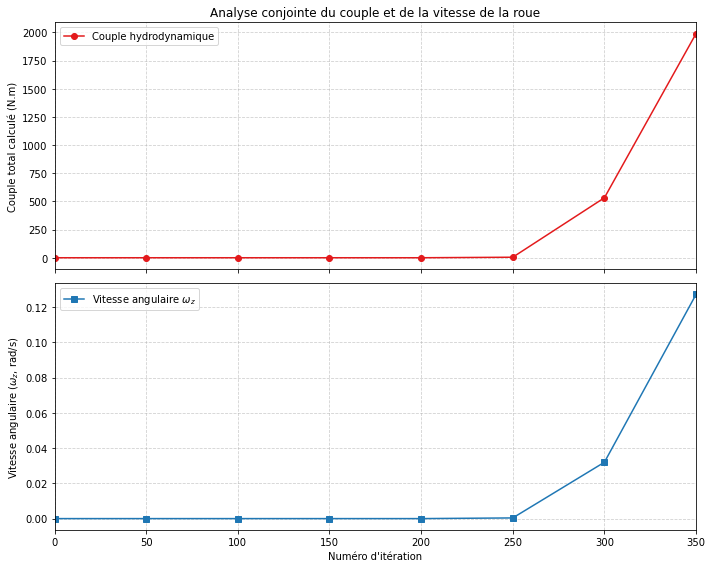

In [37]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt

def extract_data_from_vtk(vtk_path, wheel_center=(0.795, 0.40)):
    if not os.path.exists(vtk_path):
        return None

    with open(vtk_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    num_points = 0
    points = []
    pressure = []
    normals = []
    types = []
    velocity = []

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        
        if line.startswith("POINTS"):
            parts = line.split()
            num_points = int(parts[1])
            pt_lines = []
            j = i + 1
            while len(pt_lines) < num_points * 3 and j < len(lines):
                pt_lines.extend([float(x) for x in lines[j].split()])
                j += 1
            points = np.array(pt_lines).reshape((num_points, 3))
            i = j - 1
            
        elif line.startswith("SCALARS Pressure"):
            j = i + 2
            p_list = []
            while len(p_list) < num_points and j < len(lines):
                p_list.extend([float(x) for x in lines[j].split()])
                j += 1
            pressure = np.array(p_list)
            i = j - 1
            
        elif line.startswith("SCALARS Type"):
            j = i + 2
            t_list = []
            while len(t_list) < num_points and j < len(lines):
                t_list.extend([int(x) for x in lines[j].split()])
                j += 1
            types = np.array(t_list)
            i = j - 1
            
        elif line.startswith("VECTORS WallNormals"):
            j = i + 1
            n_list = []
            while len(n_list) < num_points * 3 and j < len(lines):
                n_list.extend([float(x) for x in lines[j].split()])
                j += 1
            normals = np.array(n_list).reshape((num_points, 3))
            i = j - 1

        elif line.startswith("VECTORS Velocity "):
            j = i + 1
            v_list = []
            while len(v_list) < num_points * 3 and j < len(lines):
                v_list.extend([float(x) for x in lines[j].split()])
                j += 1
            velocity = np.array(v_list).reshape((num_points, 3))
            i = j - 1
        i += 1

    points = np.array(points)
    pressure = np.array(pressure)
    types = np.array(types)
    normals = np.array(normals)
    velocity = np.array(velocity)

    if len(points) == 0:
        return None

    if len(types) == len(points):
        wheel_mask = (types == 5)
    else:
        dist = np.sqrt((points[:, 0] - wheel_center[0])**2 + (points[:, 1] - wheel_center[1])**2)
        wheel_mask = (dist > 0.04) & (dist < 0.3)

    if not np.any(wheel_mask):
        return 0.0, 0.0

    w_points = points[wheel_mask]
    
    # --- 1. CALCUL DU COUPLE ---
    torque = 0.0
    if len(pressure) == len(points):
        w_pressure = pressure[wheel_mask]
        if len(normals) == len(points):
            w_normals = normals[wheel_mask]
        else:
            rx_raw = w_points[:, 0] - wheel_center[0]
            ry_raw = w_points[:, 1] - wheel_center[1]
            r_norm = np.sqrt(rx_raw**2 + ry_raw**2)
            r_norm[r_norm == 0] = 1.0
            w_normals = np.zeros_like(w_points)
            w_normals[:, 0] = rx_raw / r_norm
            w_normals[:, 1] = ry_raw / r_norm

        fx = w_pressure * w_normals[:, 0]
        fy = w_pressure * w_normals[:, 1]
        rx = w_points[:, 0] - wheel_center[0]
        ry = w_points[:, 1] - wheel_center[1]
        torque = np.sum(rx * fy - ry * fx)

    # --- 2. CALCUL DE LA VITESSE ANGULAIRE MOYENNE (Moindres carrés) ---
    omega_z = 0.0
    if len(velocity) == len(points):
        w_velocity = velocity[wheel_mask]
        rx = w_points[:, 0] - wheel_center[0]
        ry = w_points[:, 1] - wheel_center[1]
        vx = w_velocity[:, 0]
        vy = w_velocity[:, 1]
        
        # Minimisation de l'erreur quadratique sur v_x = -omega*r_y et v_y = omega*r_x
        num = np.sum(vy * rx - vx * ry)
        den = np.sum(rx**2 + ry**2)
        if den > 0:
            omega_z = num / den

    return torque, omega_z

def main():
    directory = r"C:\Users\grenaut\Desktop\GUI test\SPHIRITv9.13\Milllagrangianwassp0dx1.0h1.2RenormFalseViscoFalse"
    vtk_files = glob.glob(os.path.join(directory, "*.vtk"))
    
    def extract_number(filepath):
        filename = os.path.basename(filepath)
        s = re.findall(r"(\d+)\.vtk$", filename)
        return int(s[0]) if s else 0

    vtk_files = sorted(vtk_files, key=extract_number)

    if not vtk_files:
        print("Aucun fichier VTK trouvé.")
        return

    iterations = []
    torques = []
    omegas = []
    wheel_center = (0.795, 0.40)

    for filepath in vtk_files:
        it = extract_number(filepath)
        res = extract_data_from_vtk(filepath, wheel_center=wheel_center)
        if res is not None:
            tq, om = res
            iterations.append(int(it))
            torques.append(float(tq))
            omegas.append(float(om))
#             print(f"Itération : {it} | Couple : {tq:.4e} N.m | Vitesse angulaire : {om:.4e} rad/s")

    x = np.array(iterations, dtype=int)
    y_torque = np.array(torques, dtype=float)
    y_omega = np.array(omegas, dtype=float)

    if len(x) == 0:
        print("Aucune donnée valide extraite.")
        return

    # Création du double graphique superposé avec axe X partagé
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Graphe supérieur : Couple
    ax1.plot(x, y_torque, "o-", color="#e31a1c", linewidth=1.5, label="Couple hydrodynamique")
    ax1.set_ylabel("Couple total calculé (N.m)")
    ax1.set_title("Analyse conjointe du couple et de la vitesse de la roue")
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.legend(loc="upper left")
    
    # Graphe inférieur : Vitesse angulaire
    ax2.plot(x, y_omega, "s-", color="#1f77b4", linewidth=1.5, label="Vitesse angulaire $\omega_z$")
    ax2.set_xlabel("Numéro d'itération")
    ax2.set_ylabel("Vitesse angulaire ($\omega_z$, rad/s)")
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.legend(loc="upper left")
    
    plt.xlim(np.min(x), np.max(x))
    plt.tight_layout()
    
    output_img = os.path.join(directory, "courbe_couple_vitesse_iterations.png")
    plt.savefig(output_img, dpi=150)
    print(f"\nGraphique enregistré sous : {output_img}")
    plt.show()

if __name__ == "__main__":
    main()